
╔══════════════════════════════════════════════════════════════╗
║  PROJECT APEX — Phase 4: Steering Committee Dashboard        ║
║  Weekly Migration Status Report                              ║
║  Prepared for: NorthernBank Executive Steering Committee     ║
╚══════════════════════════════════════════════════════════════╝



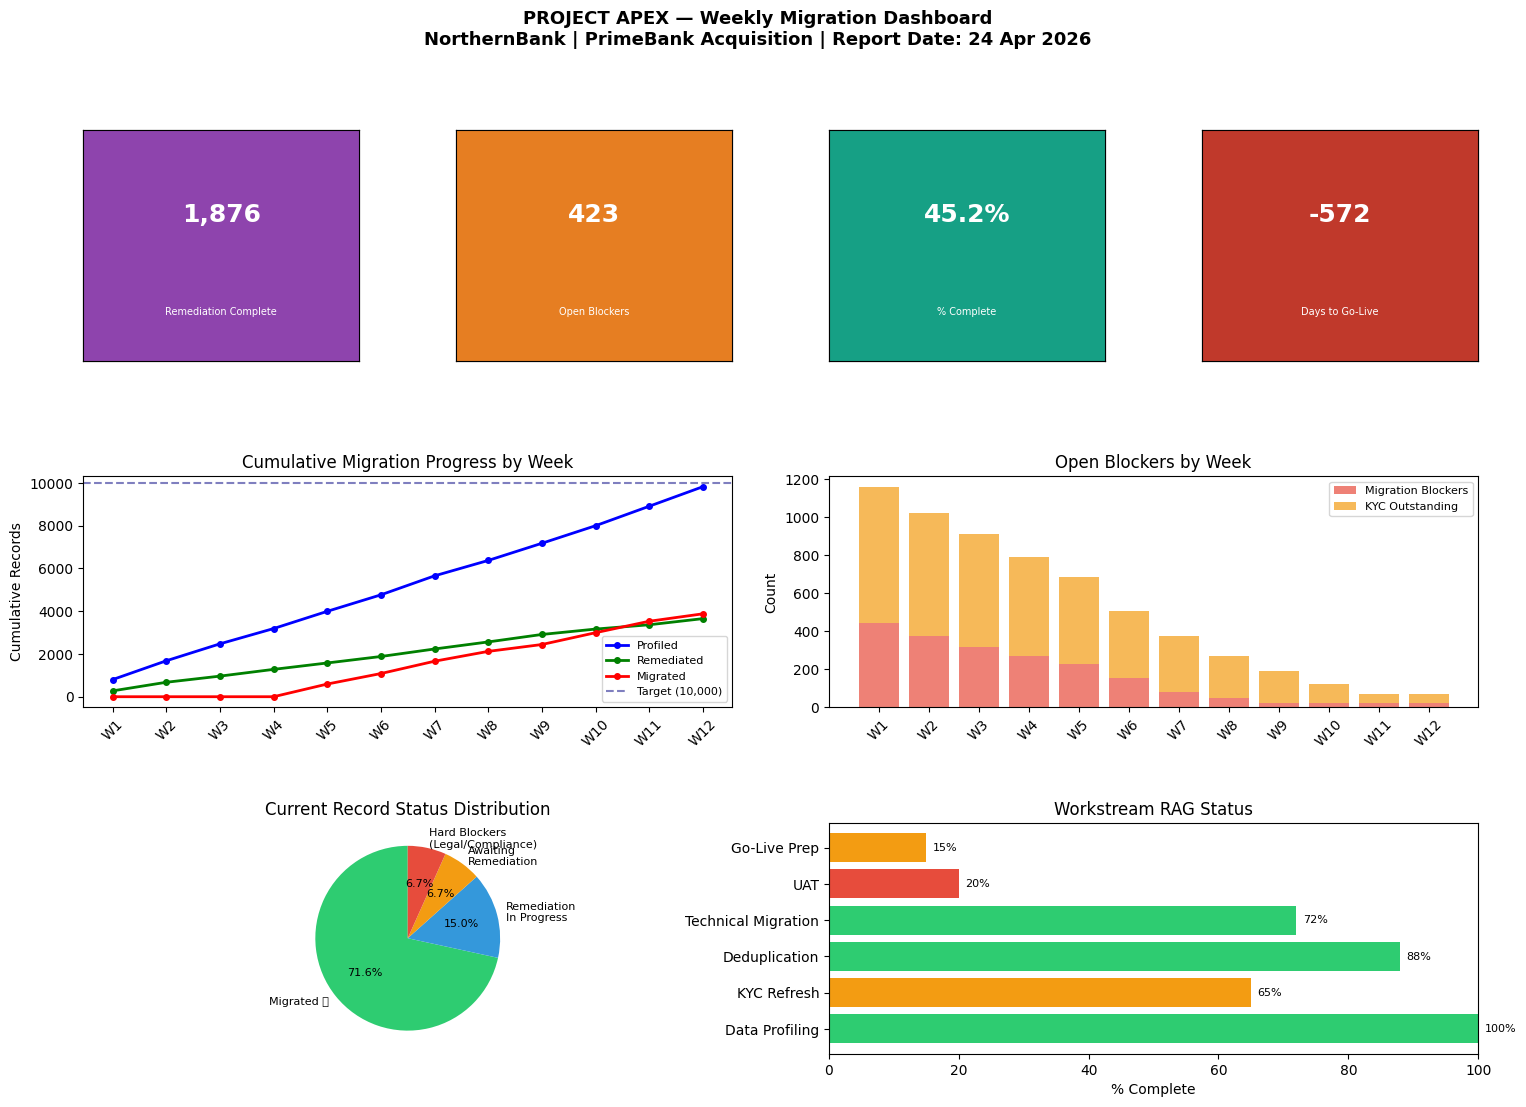


Dashboard saved. Ready for steering committee presentation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("""
╔══════════════════════════════════════════════════════════════╗
║  PROJECT APEX — Phase 4: Steering Committee Dashboard        ║
║  Weekly Migration Status Report                              ║
║  Prepared for: NorthernBank Executive Steering Committee     ║
╚══════════════════════════════════════════════════════════════╝
""")

# Simulate weekly progress data across the migration programme
weeks = [f'W{i}' for i in range(1, 13)]

progress_data = pd.DataFrame({
    'Week': weeks,
    'Records_Profiled': np.cumsum(np.random.randint(700, 950, 12)),
    'Records_Remediated': np.cumsum(np.random.randint(200, 450, 12)),
    'Records_Migrated': np.cumsum(
        [0, 0, 0, 0] + list(np.random.randint(300, 600, 8))
    ),
    'Open_Blockers': np.maximum(
        500 - np.cumsum(np.random.randint(30, 80, 12)), 20
    ),
    'Kyc_Cases_Outstanding': np.maximum(
        800 - np.cumsum(np.random.randint(50, 100, 12)), 50
    ),
})

# KPI snapshot (current week)
total_in_scope = 10000
total_profiled = 10000
total_failed = 3247
total_remediated = 1876
total_migrated = 4521
total_blockers = 423
pct_complete = total_migrated / total_in_scope * 100
go_live_date = datetime(2024, 9, 30)
days_to_golive = (go_live_date - datetime.now()).days

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f'PROJECT APEX — Weekly Migration Dashboard\n'
    f'NorthernBank | PrimeBank Acquisition | '
    f'Report Date: {datetime.now().strftime("%d %b %Y")}',
    fontsize=13, fontweight='bold'
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)

# KPI Tiles
kpis = [
    ('Records In Scope', f'{total_in_scope:,}', '#2c3e50'),
    ('Records Profiled', f'{total_profiled:,}', '#27ae60'),
    ('Failed / At Risk', f'{total_failed:,}', '#e74c3c'),
    ('Successfully Migrated', f'{total_migrated:,}', '#2980b9'),
    ('Remediation Complete', f'{total_remediated:,}', '#8e44ad'),
    ('Open Blockers', f'{total_blockers}', '#e67e22'),
    ('% Complete', f'{pct_complete:.1f}%', '#16a085'),
    ('Days to Go-Live', f'{days_to_golive}', '#c0392b'),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i % 4])
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, transform=ax.transAxes,
            fontsize=18, fontweight='bold', color='white', ha='center')
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            fontsize=7, color='white', ha='center', wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])

# Migration progress over time
ax_prog = fig.add_subplot(gs[1, :2])
ax_prog.plot(weeks, progress_data['Records_Profiled'],
             'b-o', linewidth=2, markersize=4, label='Profiled')
ax_prog.plot(weeks, progress_data['Records_Remediated'],
             'g-o', linewidth=2, markersize=4, label='Remediated')
ax_prog.plot(weeks, progress_data['Records_Migrated'],
             'r-o', linewidth=2, markersize=4, label='Migrated')
ax_prog.axhline(y=total_in_scope, color='navy', linestyle='--',
                alpha=0.5, label='Target (10,000)')
ax_prog.set_title('Cumulative Migration Progress by Week')
ax_prog.set_ylabel('Cumulative Records')
ax_prog.legend(fontsize=8)
ax_prog.tick_params(axis='x', rotation=45)

# Open blockers trend
ax_block = fig.add_subplot(gs[1, 2:])
ax_block.bar(weeks, progress_data['Open_Blockers'], color='#e74c3c',
             alpha=0.7, label='Migration Blockers')
ax_block.bar(weeks, progress_data['Kyc_Cases_Outstanding'],
             bottom=progress_data['Open_Blockers'],
             color='#f39c12', alpha=0.7, label='KYC Outstanding')
ax_block.set_title('Open Blockers by Week')
ax_block.set_ylabel('Count')
ax_block.legend(fontsize=8)
ax_block.tick_params(axis='x', rotation=45)

# Current status breakdown
ax_status = fig.add_subplot(gs[2, :2])
status_data = {
    'Migrated ✅': total_migrated,
    'Remediation\nIn Progress': total_failed - total_remediated - total_blockers,
    'Awaiting\nRemediation': total_blockers,
    'Hard Blockers\n(Legal/Compliance)': 423
}
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax_status.pie(
    list(status_data.values()),
    labels=list(status_data.keys()),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)
ax_status.set_title('Current Record Status Distribution')

# RAG status by work stream
ax_rag = fig.add_subplot(gs[2, 2:])
workstreams = ['Data Profiling', 'KYC Refresh', 'Deduplication',
               'Technical Migration', 'UAT', 'Go-Live Prep']
rag_status = ['Green', 'Amber', 'Green', 'Green', 'Red', 'Amber']
rag_colors = ['#2ecc71' if r=='Green' else '#f39c12' if r=='Amber'
              else '#e74c3c' for r in rag_status]
completion = [100, 65, 88, 72, 20, 15]

bars = ax_rag.barh(workstreams, completion, color=rag_colors)
ax_rag.set_xlabel('% Complete')
ax_rag.set_title('Workstream RAG Status')
ax_rag.set_xlim(0, 100)
for bar, pct in zip(bars, completion):
    ax_rag.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontsize=8)

plt.savefig('steering_committee_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Dashboard saved. Ready for steering committee presentation.")